In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
import os


## Functions

In [15]:
# Base directory where your files are stored

# Function to load and average accuracy files
def load_and_average_accuracy(condition):
    base_dir = "epoch_data"
    # Find all accuracy files for the condition
    acc_files = glob.glob(os.path.join(base_dir, f"{condition}_accuracy_seed*.npy"))
    
    # Load all accuracy arrays
    acc_arrays = [np.load(f) for f in acc_files]
    
    # Stack and average across seeds
    avg_acc = np.mean(acc_arrays, axis=0)
    return avg_acc

# Function to load epoch (just pick one file, since they’re identical per condition)
def load_epoch(condition):
    base_dir = "epoch_data"
    epoch_file = glob.glob(os.path.join(base_dir, f"{condition}_epoch_seed*.npy"))[0]
    return np.load(epoch_file)


In [16]:
def accuracy_analysis(tuning_type, overlap):
    base_dir = "accuracy data"
    files = glob.glob(os.path.join(base_dir, f"*'{tuning_type}'_{overlap}_overlap_accuracy_summary_seed*.csv"))
    acc = []
    for f in files:
        data = pd.read_csv(f)
        if tuning_type == 'head':
            dt = data.iloc[:12, :]
        else:
            dt = data.iloc[0, :]
            dt = pd.DataFrame(dt).T
        daa = dt['accuracy'].copy()
        acc.append(daa)

    ac = pd.concat(acc, axis=1)
    ac.columns = [f"Seed {i+1}" for i in range(len(files))]
    acm = ac.mean(axis=1)*100
    acs = ac.std(axis=1)*100

    if tuning_type == 'head':
        d = pd.read_csv(f).iloc[:12, :]
    else:
        d = pd.read_csv(f).iloc[0, :]
        d = pd.DataFrame(d).T
    d.drop(columns=['epochs', 'lr'], inplace=True)
    d['accuracy'] = (acm.round(2).astype(str) + '%' + ' ± ' + acs.round(2).astype(str) + '%').values
    if overlap != 'no':
        d['overlap'] = d['seg_len']/2

    if tuning_type == 'head':
        best_index = d["accuracy"].idxmax()
        best_row = d.loc[best_index]
        print("=== Best configuration based on accuracy ('head' fine-tuning)===")
        print(best_row)
    
    print(f"Overall mean: {acm.mean().round(2)}% and overall STD: {acm.std().round(2)}% for '{tuning_type}' tuning type")
    d.rename(columns={'accuracy': 'Accuracy (Mean ± Std Dev)'}, inplace=True)
    accuracy_mean = acm[best_index] if tuning_type == 'head' else acm[0]
    accuracy_std = acs[best_index] if tuning_type == 'head' else acs[0]
    return round(accuracy_mean, 2), round(accuracy_std, 4), d


## Usage

### No Overlapping

#### Accuracy vs Epoch

No Overlap → Best Epoch: 125, Accuracy: 0.8462


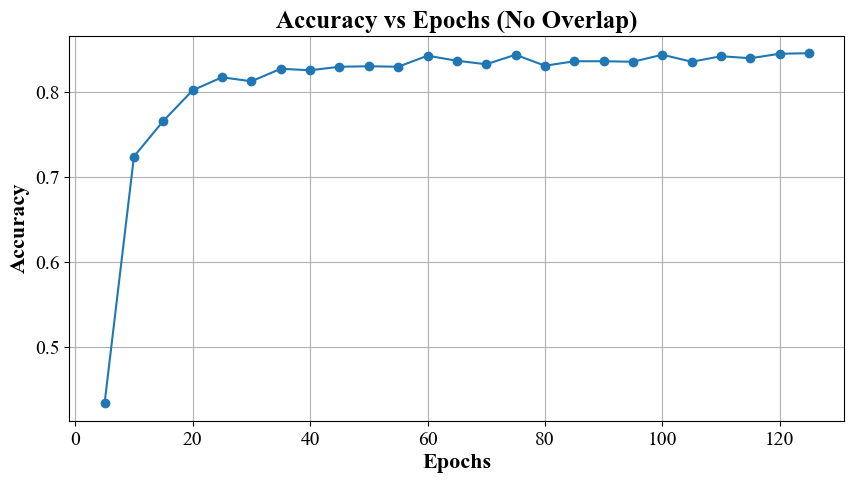

In [30]:
avg_acc_no_overlap = load_and_average_accuracy("no_overlap")
epochs_no_overlap = load_epoch("no_overlap")

# Find best epoch for each condition
best_idx_no_overlap = np.argmax(avg_acc_no_overlap)
best_epoch_no_overlap = epochs_no_overlap[best_idx_no_overlap]
best_acc_no_overlap = avg_acc_no_overlap[best_idx_no_overlap]
print(f"No Overlap → Best Epoch: {best_epoch_no_overlap}, Accuracy: {best_acc_no_overlap:.4f}")

# Plotting
plt.figure(figsize=(10,5))
plt.plot(epochs_no_overlap, avg_acc_no_overlap, marker='o')
plt.grid(True)
plt.xlabel('Epochs', fontsize=16, fontweight='bold', fontfamily='times new roman')
plt.xticks(fontsize=14)
plt.ylabel('Accuracy', fontsize=16, fontweight='bold', fontfamily='times new roman')
plt.yticks(fontsize=14)
plt.title('Accuracy vs Epochs (No Overlap)', fontsize=18, fontweight='bold', fontfamily='times new roman')
plt.savefig('results\\accuracy_plot_no_overlap.tif', dpi=300)
plt.show()


#### 'head' and 'full' fine-tuning


In [18]:
# 'head' fine-tuning
acmn, acsn, dfn = accuracy_analysis('head', 'no')
dfn.to_excel('results\\head_no_overlap_accuracy_summary.xlsx', index=False)

# 'full' fine-tuning
acmfn, acsfn, dffn = accuracy_analysis('full', 'no')
dffn.to_excel('results\\full_no_overlap_accuracy_summary.xlsx', index=False)


=== Best configuration based on accuracy ('head' fine-tuning)===
test_size               0.2
seg_len               512.0
overlap                 0.0
accuracy     84.73% ± 0.58%
Name: 9, dtype: object
Overall mean: 82.62% and overall STD: 1.0% for 'head' tuning type
Overall mean: 84.62% and overall STD: nan% for 'full' tuning type


In [19]:
acmn, acsn, acmfn, acsfn


(np.float64(84.73), np.float64(0.5767), 84.62, 1.6473)

#### 'head' vs 'full' fine-tuning plot


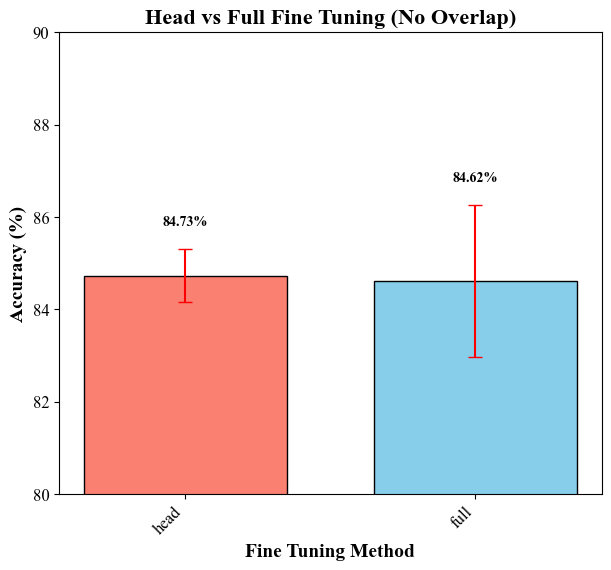

In [31]:
# Set global font to Times New Roman
plt.rcParams['font.family'] = 'Times New Roman'

# Accuracy values
conditions = ['head', 'full']
accuracies = [acmn, acmfn]  # in percent
stds = [acsn, acsfn]  # in percent

# Create bar plot
plt.figure(figsize=(7,6))
plt.bar(conditions, accuracies, ec='black',
        yerr=stds, ecolor='red', capsize=5,
        color=['salmon', 'skyblue'], width=0.7)

# Add labels and title
plt.xlabel('Fine Tuning Method', fontsize=14, fontweight='bold')  # Bold xlabel
plt.xticks(fontsize=12)  # Set x-tick font size
plt.ylabel('Accuracy (%)', fontsize=14, fontweight='bold')
plt.yticks(fontsize=12)  # Set y-tick font size
plt.title('Head vs Full Fine Tuning (No Overlap)', fontsize=16, fontweight='bold')
plt.ylim(80, 90)  # show full percentage scale
plt.xticks(rotation=45, ha='right', fontsize=12)  # Rotate x-ticks for better readability

# Annotate values on bars
# Annotate values on bars
for i, (acc, std) in enumerate(zip(accuracies, stds)):
    plt.text(
        i,
        acc + std + 0.5,   # <-- add std + small offset
        f"{acc:.2f}%",     # format nicely
        ha='center',
        fontsize=10,
        fontweight='bold'
    )
plt.savefig('results\\head_vs_full_no_overlap.tif', dpi=300)
plt.show()


### 50% Overlapping

#### Accuracy vs Epoch

50% Overlap → Best Epoch: 250, Accuracy: 0.8575


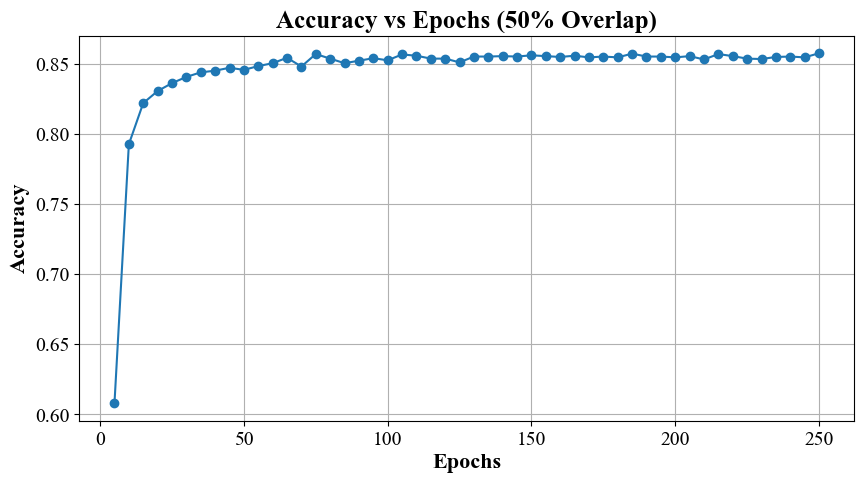

In [29]:
avg_acc_overlap = load_and_average_accuracy("50%_overlap")
epochs_overlap = load_epoch("50%_overlap")

best_idx_overlap = np.argmax(avg_acc_overlap)
best_epoch_overlap = epochs_overlap[best_idx_overlap]
best_acc_overlap = avg_acc_overlap[best_idx_overlap]
print(f"50% Overlap → Best Epoch: {best_epoch_overlap}, Accuracy: {best_acc_overlap:.4f}")

# Plotting
plt.figure(figsize=(10,5))
plt.plot(epochs_overlap, avg_acc_overlap, marker='o')
plt.grid(True)
plt.xlabel('Epochs', fontsize=16, fontweight='bold', fontfamily='times new roman')
plt.xticks(fontsize=14) 
plt.ylabel('Accuracy', fontsize=16, fontweight='bold', fontfamily='times new roman')
plt.yticks(fontsize=14)
plt.title('Accuracy vs Epochs (50% Overlap)', fontsize=18, fontweight='bold', fontfamily='times new roman')
plt.savefig('results\\accuracy_plot_50%_overlap.tif', dpi=300)
plt.show()


#### 'head' and 'full' fine-tuning


In [22]:
# 'head' fine-tuning
acmy, acsy, dfy = accuracy_analysis('head', '50%')
dfy.to_excel('results\\head_50%_overlap_accuracy_summary.xlsx', index=False)

# 'full' fine-tuning
acmfy, acsfy, dffy = accuracy_analysis('full', '50%')
dffy.to_excel('results\\full_50%_overlap_accuracy_summary.xlsx', index=False)


=== Best configuration based on accuracy ('head' fine-tuning)===
test_size               0.2
seg_len               300.0
overlap               150.0
accuracy     86.15% ± 1.06%
Name: 3, dtype: object
Overall mean: 85.29% and overall STD: 0.41% for 'head' tuning type
Overall mean: 91.88% and overall STD: nan% for 'full' tuning type


In [23]:
acmy, acsy, acmfy, acsfy  


(np.float64(86.15), np.float64(1.0571), 91.88, 1.9185)

#### 'head' vs 'full' fine-tuning plot


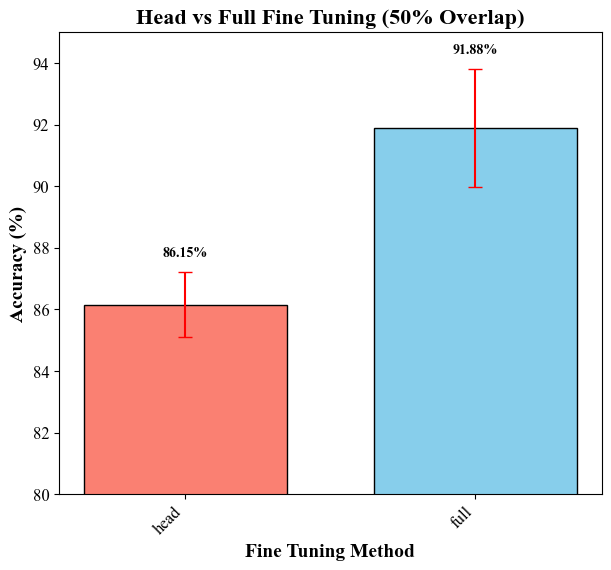

In [32]:
# Set global font to Times New Roman
plt.rcParams['font.family'] = 'Times New Roman'

# Accuracy values
conditions = ['head', 'full']
accuracies = [acmy, acmfy]  # in percent
stds = [acsy, acsfy]  # in percent

# Create bar plot
plt.figure(figsize=(7,6))
plt.bar(conditions, accuracies, ec='black',
        yerr=stds, ecolor='red', capsize=5,
        color=['salmon', 'skyblue'], width=0.7)

# Add labels and title
plt.xlabel('Fine Tuning Method', fontsize=14, fontweight='bold')  # Bold xlabel
plt.xticks(fontsize=12)  # Set x-tick font size
plt.ylabel('Accuracy (%)', fontsize=14, fontweight='bold')
plt.yticks(fontsize=12)  # Set y-tick font size
plt.title('Head vs Full Fine Tuning (50% Overlap)', fontsize=16, fontweight='bold')
plt.ylim(80, 95)  # show full percentage scale
plt.xticks(rotation=45, ha='right', fontsize=12)  # Rotate x-ticks for better readability

# Annotate values on bars
# Annotate values on bars
for i, (acc, std) in enumerate(zip(accuracies, stds)):
    plt.text(
        i,
        acc + std + 0.5,   # <-- add std + small offset
        f"{acc:.2f}%",     # format nicely
        ha='center',
        fontsize=10,
        fontweight='bold'
    )
plt.savefig('results\\head_vs_full_50%_overlap.tif', dpi=300)
plt.show()


## Subject-Invariant Analysis

In [25]:
df_full = pd.read_excel("subject-invariant data/'full'_cv_results_seedwise.xlsx")
df_head = pd.read_excel("subject-invariant data/'head'_cv_results_seedwise.xlsx")

df_head = df_head[['seed', 'mean']]
df_head_mean = df_head['mean'].mean().__round__(4) * 100
df_head_std = df_head['mean'].std().__round__(4) * 100
print(f"Mean of 'head' fine-tuning: {df_head_mean} ± {df_head_std}")

df_full = df_full[['seed', 'mean']]
df_full_mean = df_full['mean'].mean().__round__(4) * 100
df_full_std = df_full['mean'].std().__round__(4) * 100
print(f"Mean of 'full' fine-tuning: {df_full_mean} ± {df_full_std}")


Mean of 'head' fine-tuning: 79.54 ± 0.66
Mean of 'full' fine-tuning: 78.47 ± 0.54


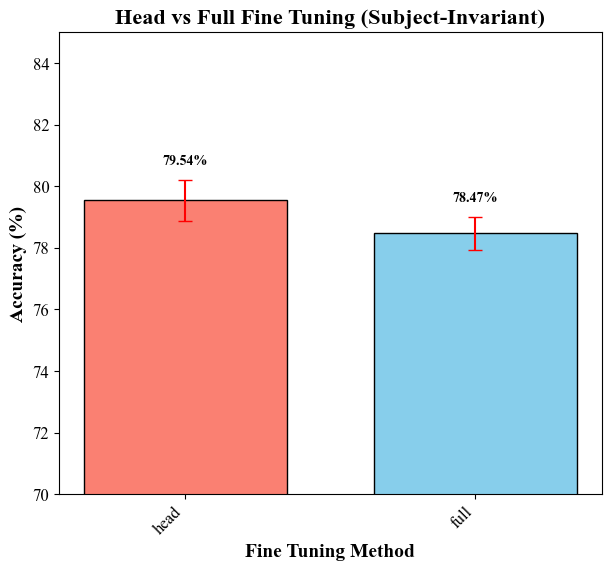

In [33]:
# Set global font to Times New Roman
plt.rcParams['font.family'] = 'Times New Roman'

# Accuracy values
conditions = ['head', 'full']
accuracies = [df_head_mean, df_full_mean]  # in percent
stds = [df_head_std, df_full_std]  # in percent

# Create bar plot
plt.figure(figsize=(7,6))
plt.bar(conditions, accuracies, ec='black',
        yerr=stds, ecolor='red', capsize=5,
        color=['salmon', 'skyblue'], width=0.7)

# Add labels and title
plt.xlabel('Fine Tuning Method', fontsize=14, fontweight='bold')  # Bold xlabel
plt.xticks(fontsize=12)  # Set x-tick font size
plt.ylabel('Accuracy (%)', fontsize=14, fontweight='bold')
plt.yticks(fontsize=12)  # Set y-tick font size
plt.title('Head vs Full Fine Tuning (Subject-Invariant)', fontsize=16, fontweight='bold')
plt.ylim(70, 85)  # show full percentage scale
plt.xticks(rotation=45, ha='right', fontsize=12)  # Rotate x-ticks for better readability

# Annotate values on bars
# Annotate values on bars
for i, (acc, std) in enumerate(zip(accuracies, stds)):
    plt.text(
        i,
        acc + std + 0.5,   # <-- add std + small offset
        f"{acc:.2f}%",     # format nicely
        ha='center',
        fontsize=10,
        fontweight='bold'
    )
plt.savefig('results\\head_vs_full_subject-invariant.tif', dpi=300)
plt.show()
